In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [4]:
from backend.dataset_loader import *
from backend.bbox_generator import *

In [5]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [10]:
mat_files = get_all_mat_files('../data/figshare/')
print(len(mat_files))

3064


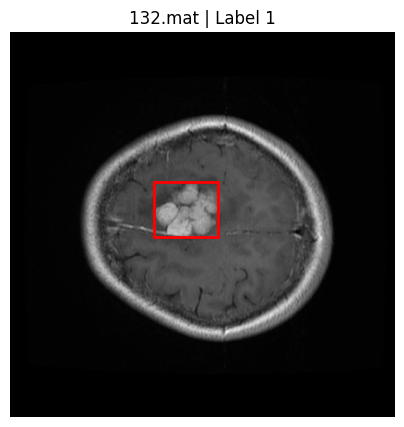

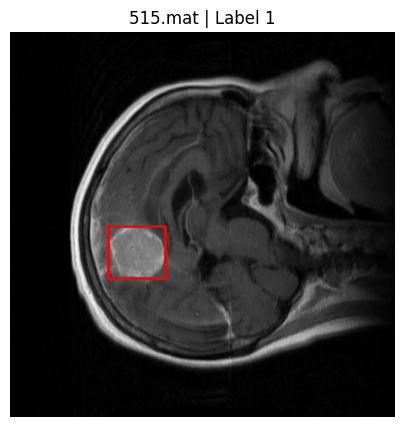

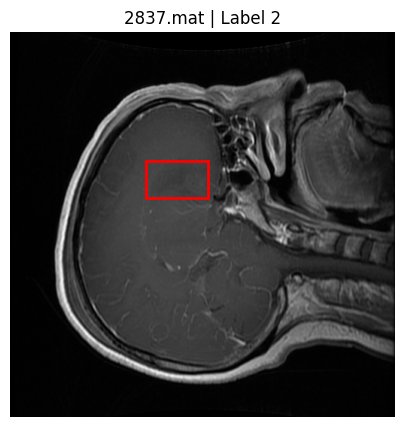

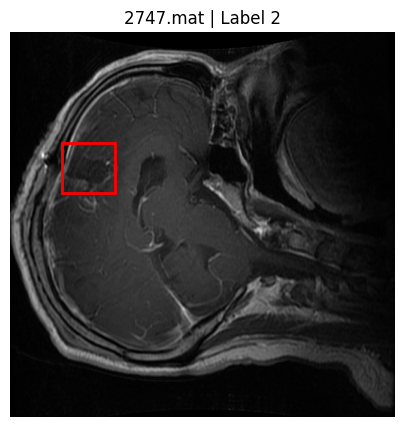

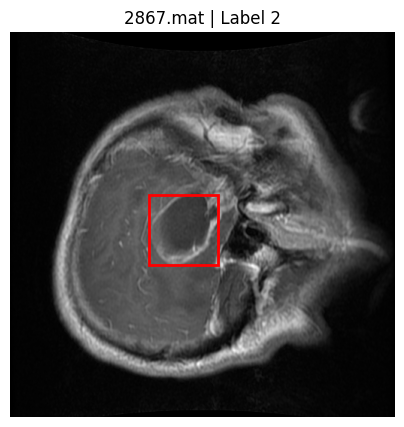

In [12]:
for _ in range(5):
    file = random.choice(mat_files)
    sample = load_sample(file)
    bbox = mask_to_bbox(sample['mask'])

    x_min, y_min, x_max, y_max = bbox

    flg, ax = plt.subplots(figsize = (5,5))

    ax.imshow(sample['image'], cmap = "gray")

    rect = patches.Rectangle(
        (x_min,y_min),
        x_max - x_min,
        y_max - y_min,
        linewidth = 2,
        edgecolor = 'red',
        facecolor = 'none'
    )

    ax.add_patch(rect)

    plt.title(
        f"{file.name} | Label {sample['label']}"
    )

    plt.axis('off')
    plt.show()

In [13]:
label_counts = {
    1 : 0,
    2 : 0,
    3 : 0
}

for file in mat_files:

    sample = load_sample(file)
    label_counts[sample["label"]] += 1

print(label_counts)

{1: 708, 2: 1426, 3: 930}


In [14]:
areas = []

for file in mat_files:
    sample = load_sample(file)

    mask = sample['mask']
    area = mask.sum()
    areas.append(area)

print('Min area:',min(areas))
print('Max area:',max(areas))
print('Average area:',sum(areas)/len(areas))

Min area: 163
Max area: 25461
Average area: 4421.717362924282
